In [4]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
# from python.polygon_based_correction import *
# from python.animation import *
from eval.eval import *
# from python.dataset_conversion import *
# from python.misprediction_classifier import *
# from autoencoder.src.data_loader import *
from interpolate import *

sleap.versions()
sleap.system_summary()


SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [7]:
pred_result_folder = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/correction/results'
pred_result_path = os.path.join(pred_result_folder, 'pred_results_v1.npy')
pred_result = np.load(pred_result_path)
print(pred_result.shape)

corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

(2999, 17, 2)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 2)


3000it [00:02, 1027.11it/s]

Missing point count: 0
reorder_idx.shape: (17,)


In [6]:
pred_missing_mask = get_missing_count(pred_result)
print(f'missing count: {np.sum(pred_missing_mask)}')

missing count: 9107.0


In [3]:
pred_result_interpolated = avg_flow_interpolate(pred_result, window_size=4, verbose=False)

In [5]:
pred_interp_missing_mask = get_missing_count(pred_result_interpolated)
print(f'missing count: {np.sum(pred_interp_missing_mask)}')

missing count: 11.0


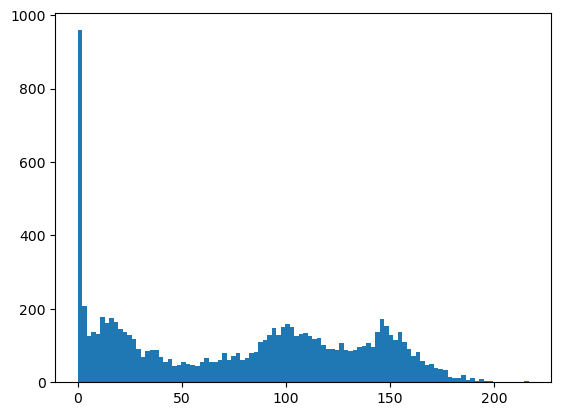

mean: 78.33210776147217, std: 56.45475028387777, max: 216.6577392456148


In [10]:
all_interp_err = np.linalg.norm((pred_result_interpolated - gt_pts[1:])[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')